<a href="https://colab.research.google.com/github/manuc18/AI_Digital_Health_Agent/blob/main/Copy_of_AI_Digital_Health_Agent_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import kagglehub
# hrezaeiyork_meddialogue_path = kagglehub.dataset_download('hrezaeiyork/meddialogue')

print('Data source import complete.')


Data source import complete.


In [ ]:
import json
import pandas as pd
import os
from tqdm import tqdm

# Set pandas display options
pd.set_option('display.max_colwidth', None)


# 1. Data Preprocessing


**Load JSON Files**

In [ ]:
with open('/content/MedDialog/english-train.json', 'r') as f:
    data = json.load(f)

print(f"Total dialogues: {len(data)}")



Total dialogues: 482


**Flatten JSON → DataFrame**

In [ ]:
records = []
for dialogue in tqdm(data):
    description = dialogue.get('description', '')
    utterances = dialogue.get('utterances', [])
    # Safely get doctor response: Usually the second utterance, after 'patient: ...'
    doctor_response = ''
    if len(utterances) >= 2 and utterances[1].startswith("doctor:"):
        doctor_response = utterances[1][len("doctor:"):].strip()
    records.append({
        'patient_query': description,
        'doctor_response': doctor_response
    })

df = pd.DataFrame(records)
df.head()




100%|██████████| 482/482 [00:00<00:00, 157880.09it/s]


,patient_query,doctor_response
0,"throat a bit sore and want to get a good imune booster, especially in light of the virus. please advise. have not been in contact with nyone with the virus.","during this pandemic. throat pain can be from a strep throat infection (antibiotics needed), a cold or influenza or other virus, or from some other cause such as allergies or irritants. usually, a person sees the doctor (call first) if the sore throat is bothersome, recurrent, or doesn't go away quickly. covid-19 infections tend to have cough, whereas strep throat usually lacks cough but has more throat pain. (3/21/20)"
1,"hey there i have had cold ""symptoms"" for over a week and had a low grade fever last week. for the past two days i have been feeling dizzy. should i contact my dr? should i see a dr","yes. protection. it is not enough symptoms to say that you are a suspect case of covid19; but, independently of this, if you have been in contact with a case, or you present persistent cough (with or without sputum), shortness of breath, wheezing, or you have a chronic disease like diabetes, hypertension, low immune system or cancer, should ask for medical attention. and use all the protection measures."
2,"i have a tight and painful chest with a dry cough, no fever and no headaches. could it possibly be coronavirus?","possible. top symptoms include fever, dry cough and sob. an obvious possibility. if so, your best step is to self-quarntine. remember at your age low risk of complication and typically will pass without issue. if worsening sob be seen. call your provider or check with local health department. these are healthtap guidelines:https://www.healthtap.com/blog/covid-19-care-guidelines/self-quarantine-guide."
3,what will happen after the incubation period for covid 19?,"in brief: symptoms if you are infected, symptoms will emerge: tiredness, dry cough, fever worsening over 5-14 days. you will also become more infective so self-isolation and good hygiene are vital.only be concerned about covid-19 if: - you have been in contact with someone with a conformed diagnosis of covid-19 - you have visited a high risk area - symptoms worsen and include persistent fever and dry cough would you like to video or text chat with me?"
4,suggest treatment for pneumonia,"thanks for your question on healthcare magic.i can understand your concern. pneumonia with pregnancy is always critical.antibiotics as early as possible is the treatment of choice for pneumonia. so better to immediately consult doctor and start antibiotics for pneumonia. drink plenty of fluids orally and keep yourself hydrated. with prompt and appropriate treatment, pneumonia can be cured easily. hope i have solved your query. i will be happy to help you further. wish you good health. thanks."


**Clean the Text**

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s.,?!]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['patient_query'] = df['patient_query'].apply(clean_text)
df['doctor_response'] = df['doctor_response'].apply(clean_text)


**Handle Missing Values**

In [ ]:
df.dropna(subset=['patient_query', 'doctor_response'], inplace=True)
df = df[df['patient_query'] != '']
df = df[df['doctor_response'] != '']


**Save Cleaned Data**

In [ ]:
os.makedirs('/content/processed', exist_ok=True)
df.to_csv('/content/processed/meddialog_cleaned.csv', index=False)
print("✅ Cleaned data saved successfully!")


✅ Cleaned data saved successfully!


# Exploratory Data Analysis (EDA)



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter


In [ ]:
df = pd.read_csv('/content/processed/meddialog_cleaned.csv')
print("Shape:", df.shape)
df.head()


Shape: (482, 2)


,patient_query,doctor_response
0,"throat a bit sore and want to get a good imune booster, especially in light of the virus. please advise. have not been in contact with nyone with the virus.","during this pandemic. throat pain can be from a strep throat infection antibiotics needed, a cold or influenza or other virus, or from some other cause such as allergies or irritants. usually, a person sees the doctor call first if the sore throat is bothersome, recurrent, or doesnt go away quickly. covid19 infections tend to have cough, whereas strep throat usually lacks cough but has more throat pain. 32120"
1,hey there i have had cold symptoms for over a week and had a low grade fever last week. for the past two days i have been feeling dizzy. should i contact my dr? should i see a dr,"yes. protection. it is not enough symptoms to say that you are a suspect case of covid19 but, independently of this, if you have been in contact with a case, or you present persistent cough with or without sputum, shortness of breath, wheezing, or you have a chronic disease like diabetes, hypertension, low immune system or cancer, should ask for medical attention. and use all the protection measures."
2,"i have a tight and painful chest with a dry cough, no fever and no headaches. could it possibly be coronavirus?","possible. top symptoms include fever, dry cough and sob. an obvious possibility. if so, your best step is to selfquarntine. remember at your age low risk of complication and typically will pass without issue. if worsening sob be seen. call your provider or check with local health department. these are healthtap guidelineshttpswww.healthtap.comblogcovid19careguidelinesselfquarantineguide."
3,what will happen after the incubation period for covid 19?,"in brief symptoms if you are infected, symptoms will emerge tiredness, dry cough, fever worsening over 514 days. you will also become more infective so selfisolation and good hygiene are vital.only be concerned about covid19 if you have been in contact with someone with a conformed diagnosis of covid19 you have visited a high risk area symptoms worsen and include persistent fever and dry cough would you like to video or text chat with me?"
4,suggest treatment for pneumonia,"thanks for your question on healthcare magic.i can understand your concern. pneumonia with pregnancy is always critical.antibiotics as early as possible is the treatment of choice for pneumonia. so better to immediately consult doctor and start antibiotics for pneumonia. drink plenty of fluids orally and keep yourself hydrated. with prompt and appropriate treatment, pneumonia can be cured easily. hope i have solved your query. i will be happy to help you further. wish you good health. thanks."


In [ ]:
df['dialogue_id'] = range(1, len(df) + 1)
print("Unique dialogues:", df['dialogue_id'].nunique())


Unique dialogues: 482


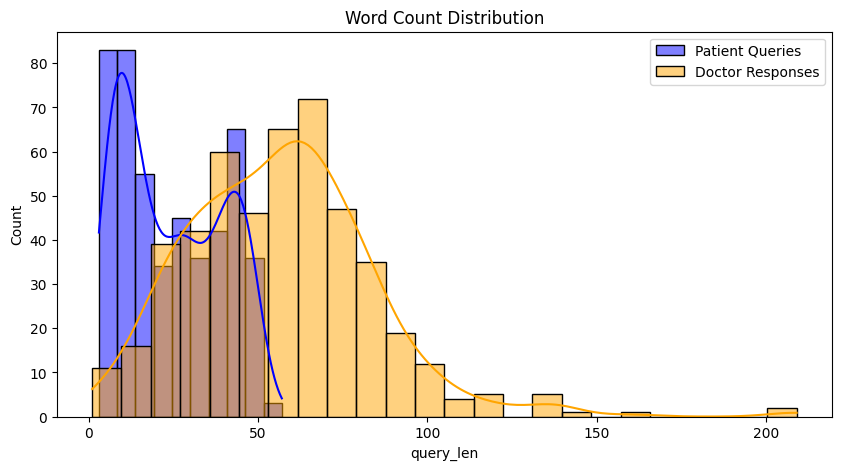

In [ ]:
df['query_len'] = df['patient_query'].str.split().apply(len)
df['response_len'] = df['doctor_response'].str.split().apply(len)

plt.figure(figsize=(10,5))
sns.histplot(df['query_len'], color='blue', label='Patient Queries', kde=True)
sns.histplot(df['response_len'], color='orange', label='Doctor Responses', kde=True)
plt.legend()
plt.title("Word Count Distribution")
plt.show()


In [ ]:
def get_top_words(texts, n=20):
    all_words = ' '.join(texts).split()
    return Counter(all_words).most_common(n)

print("Top words in patient queries:")
print(get_top_words(df['patient_query']))

print("\nTop words in doctor responses:")
print(get_top_words(df['doctor_response']))


Top words in patient queries:
[('i', 579), ('a', 349), ('and', 341), ('to', 259), ('the', 246), ('have', 242), ('for', 227), ('my', 167), ('of', 164), ('is', 163), ('in', 146), ('with', 136), ('be', 98), ('what', 89), ('should', 88), ('it', 88), ('can', 84), ('am', 78), ('get', 77), ('symptoms', 77)]

Top words in doctor responses:
[('to', 819), ('you', 733), ('and', 619), ('the', 534), ('or', 505), ('your', 502), ('with', 446), ('is', 435), ('in', 430), ('a', 419), ('of', 402), ('for', 355), ('if', 331), ('be', 300), ('have', 282), ('are', 257), ('like', 237), ('i', 236), ('would', 224), ('not', 208)]


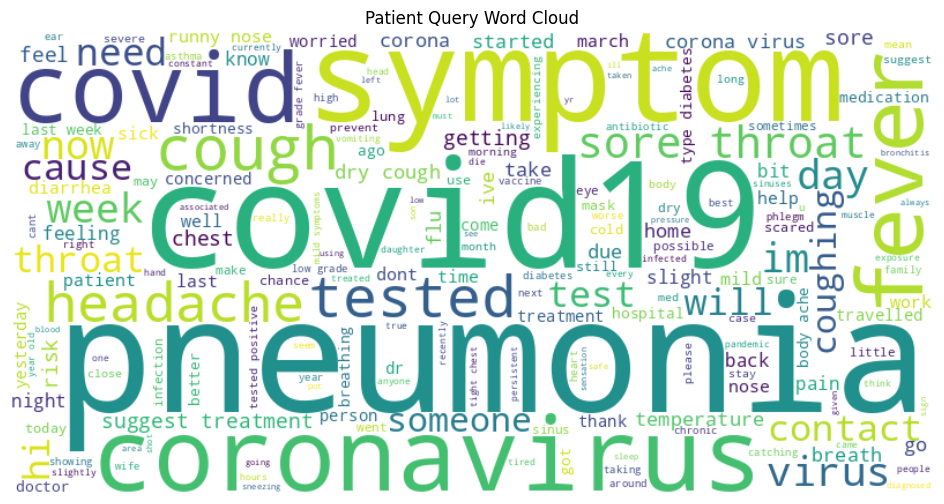

In [ ]:
plt.figure(figsize=(12,6))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df['patient_query']))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Patient Query Word Cloud")
plt.show()


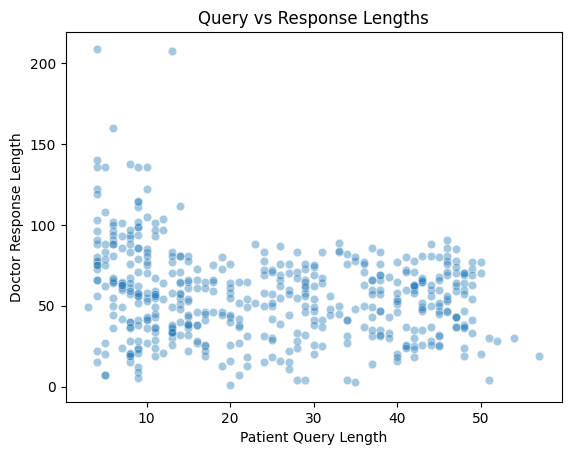

In [ ]:
sns.scatterplot(x='query_len', y='response_len', data=df, alpha=0.4)
plt.title("Query vs Response Lengths")
plt.xlabel("Patient Query Length")
plt.ylabel("Doctor Response Length")
plt.show()


In [ ]:
stats = {
    "avg_query_len": df['query_len'].mean(),
    "avg_response_len": df['response_len'].mean(),
    "total_samples": len(df)
}

pd.DataFrame([stats]).to_csv('/content/processed/data_stats.csv', index=False)
print("✅ EDA complete — summary saved!")


✅ EDA complete — summary saved!


# Symptom Lexicon & Weak Labeling

In [ ]:
!pip install --upgrade --no-cache-dir transformers datasets seqeval accelerate scikit-learn tokenizers

import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import json

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset, load_metric

# reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


ImportError: cannot import name 'load_metric' from 'datasets' (/usr/local/lib/python3.12/dist-packages/datasets/__init__.py)

In [ ]:
!pip uninstall -y pyarrow datasets transformers peft huggingface-hub
!pip install pyarrow datasets transformers==4.30.0 peft==0.4.0 huggingface-hub==0.16.4

Found existing installation: pyarrow 22.0.0
Uninstalling pyarrow-22.0.0:
  Successfully uninstalled pyarrow-22.0.0
Found existing installation: datasets 4.3.0
Uninstalling datasets-4.3.0:
  Successfully uninstalled datasets-4.3.0
Found existing installation: transformers 4.45.2
Uninstalling transformers-4.45.2:
  Successfully uninstalled transformers-4.45.2
Found existing installation: peft 0.17.1
Uninstalling peft-0.17.1:
  Successfully uninstalled peft-0.17.1
Found existing installation: huggingface-hub 0.24.6
Uninstalling huggingface-hub-0.24.6:
  Successfully uninstalled huggingface-hub-0.24.6
  Using cached pyarrow-22.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.2 kB)
  Using cached datasets-4.3.0-py3-none-any.whl.metadata (18 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 23.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... 

In [ ]:
DATA_PATH = "/content/processed/meddialog_cleaned.csv"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Please ensure preprocessing output exists at {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print("Loaded shape:", df.shape)
df.head()


Loaded shape: (482, 2)


,patient_query,doctor_response
0,"throat a bit sore and want to get a good imune booster, especially in light of the virus. please advise. have not been in contact with nyone with the virus.","during this pandemic. throat pain can be from a strep throat infection antibiotics needed, a cold or influenza or other virus, or from some other cause such as allergies or irritants. usually, a person sees the doctor call first if the sore throat is bothersome, recurrent, or doesnt go away quickly. covid19 infections tend to have cough, whereas strep throat usually lacks cough but has more throat pain. 32120"
1,hey there i have had cold symptoms for over a week and had a low grade fever last week. for the past two days i have been feeling dizzy. should i contact my dr? should i see a dr,"yes. protection. it is not enough symptoms to say that you are a suspect case of covid19 but, independently of this, if you have been in contact with a case, or you present persistent cough with or without sputum, shortness of breath, wheezing, or you have a chronic disease like diabetes, hypertension, low immune system or cancer, should ask for medical attention. and use all the protection measures."
2,"i have a tight and painful chest with a dry cough, no fever and no headaches. could it possibly be coronavirus?","possible. top symptoms include fever, dry cough and sob. an obvious possibility. if so, your best step is to selfquarntine. remember at your age low risk of complication and typically will pass without issue. if worsening sob be seen. call your provider or check with local health department. these are healthtap guidelineshttpswww.healthtap.comblogcovid19careguidelinesselfquarantineguide."
3,what will happen after the incubation period for covid 19?,"in brief symptoms if you are infected, symptoms will emerge tiredness, dry cough, fever worsening over 514 days. you will also become more infective so selfisolation and good hygiene are vital.only be concerned about covid19 if you have been in contact with someone with a conformed diagnosis of covid19 you have visited a high risk area symptoms worsen and include persistent fever and dry cough would you like to video or text chat with me?"
4,suggest treatment for pneumonia,"thanks for your question on healthcare magic.i can understand your concern. pneumonia with pregnancy is always critical.antibiotics as early as possible is the treatment of choice for pneumonia. so better to immediately consult doctor and start antibiotics for pneumonia. drink plenty of fluids orally and keep yourself hydrated. with prompt and appropriate treatment, pneumonia can be cured easily. hope i have solved your query. i will be happy to help you further. wish you good health. thanks."


In [ ]:
# A starter medical-symptom lexicon (expand this later)
SYMPTOM_LEXICON = [
    "fever", "high fever", "cough", "sore throat", "chest pain", "shortness of breath",
    "breathlessness", "headache", "nausea", "vomiting", "diarrhea", "abdominal pain",
    "stomach ache", "dizziness", "fatigue", "tired", "body ache", "muscle pain",
    "joint pain", "swelling", "runny nose", "congestion", "sneezing", "loss of taste",
    "loss of smell", "chills", "shivering", "rash", "itching", "palpitations", "dizzy",
    "breathing difficulty", "breath difficulty", "bleeding", "urinary pain"
]

# normalize lexicon (lowercase)
SYMPTOM_LEXICON = sorted(list(set([s.lower() for s in SYMPTOM_LEXICON])), key=lambda x: -len(x))
SYMPTOM_LEXICON[:10], len(SYMPTOM_LEXICON)


(['breathing difficulty',
  'shortness of breath',
  'breath difficulty',
  'abdominal pain',
  'breathlessness',
  'loss of taste',
  'loss of smell',
  'stomach ache',
  'urinary pain',
  'palpitations'],
 35)

In [ ]:
import re

def simple_tokenize(text):
    # whitespace tokenization, keep punctuation attached (we'll rely on tokenizer alignment later)
    tokens = re.findall(r"\w+|[^\w\s]", str(text).lower())
    return tokens

def lexicon_label_tokens(text, lexicon):
    tokens = simple_tokenize(text)
    labels = ["O"] * len(tokens)
    joined = " ".join(tokens)
    # For robust matching, we attempt phrase matching using sliding window
    for phrase in lexicon:
        phrase_tokens = phrase.split()
        L = len(phrase_tokens)
        if L == 0:
            continue
        # slide
        for i in range(len(tokens) - L + 1):
            window = tokens[i:i+L]
            if window == phrase_tokens:
                # mark BIO
                labels[i] = "B-SYM"
                for j in range(i+1, i+L):
                    labels[j] = "I-SYM"
    return tokens, labels

# quick sanity check
text = "I have a high fever and sore throat with cough."
print(simple_tokenize(text))
print(lexicon_label_tokens(text, SYMPTOM_LEXICON))


['i', 'have', 'a', 'high', 'fever', 'and', 'sore', 'throat', 'with', 'cough', '.']
(['i', 'have', 'a', 'high', 'fever', 'and', 'sore', 'throat', 'with', 'cough', '.'], ['O', 'O', 'O', 'B-SYM', 'B-SYM', 'O', 'B-SYM', 'I-SYM', 'O', 'B-SYM', 'O'])


In [ ]:
MAX_SAMPLES = 20000  # adjust based on compute - set lower for quick runs
rows = []
pbar = tqdm(df['patient_query'].fillna("").astype(str).tolist()[:MAX_SAMPLES], desc="Labeling")
for text in pbar:
    tokens, tags = lexicon_label_tokens(text, SYMPTOM_LEXICON)
    # only keep examples with at least one symptom token OR we can also include negatives
    rows.append({"text": text, "tokens": tokens, "labels": tags})

dataset_df = pd.DataFrame(rows)
print("Total weak-labeled rows:", len(dataset_df))
dataset_df.sample(5)


Labeling:   0%|          | 0/482 [00:00<?, ?it/s]

Total weak-labeled rows: 482


,text,tokens,labels
87,what causes persistent pneumonia?,"[what, causes, persistent, pneumonia, ?]","[O, O, O, O, O]"
261,i have been exposed to someone with covid do i qualify for a test at a laboratory?,"[i, have, been, exposed, to, someone, with, covid, do, i, qualify, for, a, test, at, a, laboratory, ?]","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O]"
180,does getting covid19 make you immune to a reinfection or just less likely to be reinfected?,"[does, getting, covid19, make, you, immune, to, a, reinfection, or, just, less, likely, to, be, reinfected, ?]","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O]"
479,"how do i know if i have a normal cold or maybe the corona virus. my sinuses are congested and i have a post nasal drip which causes sporadic episodes of dry cough outbreaks. i dont have a fever, but my body is stiff since i hiked 100km in 4 days.?","[how, do, i, know, if, i, have, a, normal, cold, or, maybe, the, corona, virus, ., my, sinuses, are, congested, and, i, have, a, post, nasal, drip, which, causes, sporadic, episodes, of, dry, cough, outbreaks, ., i, dont, have, a, fever, ,, but, my, body, is, stiff, since, i, hiked, 100km, in, 4, days, ., ?]","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, B-SYM, O, O, O, O, O, O, B-SYM, O, O, O, O, O, O, O, O, O, O, O, O, O, O, O]"
89,suggest treatment for pneumonia,"[suggest, treatment, for, pneumonia]","[O, O, O, O]"


In [ ]:
labels_list = ["O", "B-SYM", "I-SYM"]
label_to_id = {l:i for i,l in enumerate(labels_list)}
id_to_label = {i:l for l,i in label_to_id.items()}
label_to_id, id_to_label


({'O': 0, 'B-SYM': 1, 'I-SYM': 2}, {0: 'O', 1: 'B-SYM', 2: 'I-SYM'})

# Toolkit Setup for Symptom Extraction


In [ ]:
!pip install -U "transformers==4.45.2" "huggingface-hub==0.24.6"



  Using cached transformers-4.45.2-py3-none-any.whl.metadata (44 kB)
  Using cached huggingface_hub-0.24.6-py3-none-any.whl.metadata (13 kB)
  Using cached tokenizers-0.20.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached transformers-4.45.2-py3-none-any.whl (9.9 MB)
Using cached huggingface_hub-0.24.6-py3-none-any.whl (417 kB)
Using cached tokenizers-0.20.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.0 MB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.36.0
    Uninstalling huggingface-hub-0.36.0:
      Successfully uninstalled huggingface-hub-0.36.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.1
    Uninstalling tokenizers-0.22.1:
      Successfully uninstalled tokenizers-0.22.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.1
    Uninstalling transformers-4.57.1:
      Successfully uninstalled transfor

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch

# Step 1: Load the model and tokenizer
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME)

# Step 2: Prepare a simple input text
text = "The patient was prescribed [MASK] for the treatment of diabetes."

# Step 3: Tokenize input
inputs = tokenizer(text, return_tensors="pt")

# Step 4: Run the model
with torch.no_grad():
    outputs = model(**inputs)

# Step 5: Get prediction for the [MASK] token
mask_token_index = torch.where(inputs["input_ids"] == tokenizer.mask_token_id)[1]
mask_token_logits = outputs.logits[0, mask_token_index, :]
predicted_token_id = mask_token_logits.argmax(axis=-1)
predicted_token = tokenizer.decode(predicted_token_id)

print(f"Predicted word for [MASK]: {predicted_token}")


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertForMaskedLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Predicted word for [MASK]: insulin


In [ ]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    id2label=id_to_label,
    label2id=label_to_id
)


Some weights of BertForTokenClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
!pip uninstall -y transformers huggingface_hub accelerate datasets tokenizers safetensors
!pip install transformers==4.44.2 huggingface_hub==0.25.2 accelerate==0.34.2 datasets==2.21.0 tokenizers==0.19.1 safetensors



Found existing installation: transformers 4.57.1
Uninstalling transformers-4.57.1:
  Successfully uninstalled transformers-4.57.1
Found existing installation: huggingface-hub 0.36.0
Uninstalling huggingface-hub-0.36.0:
  Successfully uninstalled huggingface-hub-0.36.0
Found existing installation: accelerate 1.11.0
Uninstalling accelerate-1.11.0:
  Successfully uninstalled accelerate-1.11.0
Found existing installation: datasets 4.3.0
Uninstalling datasets-4.3.0:
  Successfully uninstalled datasets-4.3.0
Found existing installation: tokenizers 0.22.1
Uninstalling tokenizers-0.22.1:
  Successfully uninstalled tokenizers-0.22.1
Found existing installation: safetensors 0.6.2
Uninstalling safetensors-0.6.2:
  Successfully uninstalled safetensors-0.6.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.2 MB/s eta 0:00:00
  Using cached accelerate-0.34.2-py3-none-any.whl.metadata (19 kB)
  Using cached datasets-2.21.0-py3-none-any.whl.metadata (21 kB)
  Using cached fsspec-2024.6.1-p

In [ ]:
!pip install peft==0.11.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 8.5 MB/s eta 0:00:00


In [ ]:
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification

RANDOM_SEED = 42
num_labels = len(labels_list)
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

data_collator = DataCollatorForTokenClassification(tokenizer)

training_args = TrainingArguments(
    output_dir="./ner_checkpoint",
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    learning_rate=5e-5,
    save_total_limit=2,
    seed=RANDOM_SEED,
    fp16=torch.cuda.is_available(),
    report_to="none"
)


Some weights of BertForTokenClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from datasets import Dataset

hf_ds = Dataset.from_pandas(dataset_df)
hf_ds = hf_ds.train_test_split(test_size=0.1, seed=RANDOM_SEED)
train_ds = hf_ds["train"]
valid_ds = hf_ds["test"]

def align_labels_with_tokens(example):
    tokens = example["tokens"]
    labels = example["labels"]
    tokenized = tokenizer(tokens, is_split_into_words=True, truncation=True, max_length=128)
    word_ids = tokenized.word_ids()
    aligned_labels = []
    previous_word_idx = None
    for word_idx in word_ids:
        if word_idx is None:
            aligned_labels.append(-100)
        elif word_idx != previous_word_idx:
            aligned_labels.append(label_to_id[labels[word_idx]])
        else:
            lab = labels[word_idx]
            aligned_labels.append(label_to_id["I-SYM"] if lab == "B-SYM" else label_to_id[lab])
        previous_word_idx = word_idx
    tokenized["labels"] = aligned_labels
    return tokenized

train_tokenized = train_ds.map(
    lambda x: align_labels_with_tokens(x),
    batched=False,
    remove_columns=train_ds.column_names
)
valid_tokenized = valid_ds.map(
    lambda x: align_labels_with_tokens(x),
    batched=False,
    remove_columns=valid_ds.column_names
)


Map:   0%|          | 0/433 [00:00<?, ? examples/s]

Map:   0%|          | 0/49 [00:00<?, ? examples/s]

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=valid_tokenized,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
1,0.175300,0.050117
2,0.024400,0.028210


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
